# Milestone-2

# Visual Exploration and Delay Trends

**AirFly Insights – Airline Operations Analysis**

**This milestone focuses on visual exploration of airline data to understand patterns in airline traffic, delay trends, and operational performance.**

**Using visualization techniques, we analyze:**

Flight distribution

Busiest airlines and routes

Delay patterns

Delay causes

Time-based delay trends

**These visual insights help identify high-traffic airlines, delay-prone routes, and operational inefficiencies.**

# Objective

**The objective of Milestone 2 is to:**

Perform univariate and bivariate analysis

Identify top airlines and busiest routes

Analyze flight distribution across time

Study delay patterns

Compare different delay causes

Generate visual insights using graphs

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load Cleaned Dataset
df = pd.read_csv("/content/drive/MyDrive/CA-2/airline_Cleaned_data.csv")
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,DEP_HOUR,ARR_HOUR,ROUTE,IS_DELAYED
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,1065.0,0.0,0.0,0.0,0.0,0.0,11,15,FLL-EWR,0
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,1399.0,0.0,0.0,0.0,0.0,0.0,21,23,MSP-SEA,0
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,680.0,0.0,0.0,0.0,0.0,0.0,9,12,DEN-MSP,0
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,1589.0,0.0,0.0,24.0,0.0,0.0,16,18,MSP-SFO,1
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,985.0,0.0,0.0,0.0,0.0,0.0,18,20,MCO-DFW,0


# Dataset Overview

In [ ]:
df.shape

(3000000, 36)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 36 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                int64  
 21  CANCELLA

In [ ]:
df.describe()

,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,...,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,DEP_HOUR,ARR_HOUR,IS_DELAYED
count,3.000000e+06,3.000000e+06,3.000000e+06,2.922385e+06,3.000000e+06,2.921194e+06,2.921194e+06,2.920056e+06,2.920056e+06,3.000000e+06,...,2.913802e+06,3.000000e+06,3.000000e+06,3.000000e+06,3.000000e+06,3.000000e+06,3.000000e+06,3.000000e+06,3.000000e+06,3.000000e+06
mean,1.997629e+04,2.511536e+03,1.327062e+03,1.329776e+03,9.861321e+00,1.664305e+01,1.352361e+03,1.462500e+03,7.678982e+00,1.490561e+03,...,1.123108e+02,8.093616e+02,4.405987e+00,7.091943e-01,2.342720e+00,2.596900e-02,4.532725e+00,1.300111e+01,1.461053e+01,3.260490e-01
std,3.772846e+02,1.747258e+03,4.858789e+02,4.993101e+02,4.863687e+01,9.192901e+00,5.008727e+02,5.272368e+02,6.269639e+00,5.115476e+02,...,6.975484e+01,5.878939e+02,3.172305e+01,1.375707e+01,1.486748e+01,1.512105e+00,2.546245e+01,4.835019e+00,5.112877e+00,4.687655e-01
min,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,8.000000e+00,2.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.979000e+04,1.051000e+03,9.150000e+02,9.160000e+02,-6.000000e+00,1.100000e+01,9.310000e+02,1.049000e+03,4.000000e+00,1.107000e+03,...,6.100000e+01,3.770000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+00,1.100000e+01,0.000000e+00
50%,1.993000e+04,2.152000e+03,1.320000e+03,1.323000e+03,-2.000000e+00,1.400000e+01,1.336000e+03,1.501000e+03,6.000000e+00,1.516000e+03,...,9.500000e+01,6.510000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.300000e+01,1.500000e+01,0.000000e+00
75%,2.036800e+04,3.797000e+03,1.730000e+03,1.739000e+03,6.000000e+00,1.900000e+01,1.752000e+03,1.908000e+03,9.000000e+00,1.919000e+03,...,1.420000e+02,1.046000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.700000e+01,1.900000e+01,1.000000e+00
max,2.045200e+04,9.562000e+03,2.359000e+03,2.400000e+03,2.966000e+03,1.840000e+02,2.400000e+03,2.400000e+03,2.490000e+02,2.400000e+03,...,6.920000e+02,5.812000e+03,2.934000e+03,1.653000e+03,1.741000e+03,1.185000e+03,2.557000e+03,2.300000e+01,2.400000e+01,1.000000e+00


In [ ]:
df.columns

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT', 'DEP_HOUR', 'ARR_HOUR', 'ROUTE',
       'IS_DELAYED'],
      dtype='object')

**Feature Engineering**


To analyze monthly and weekly trends, new features are created from the flight date column.

In [ ]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

df['MONTH'] = df['FL_DATE'].dt.month

df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek

# **Visualization 1**

**1. Flight Distribution by Airline**

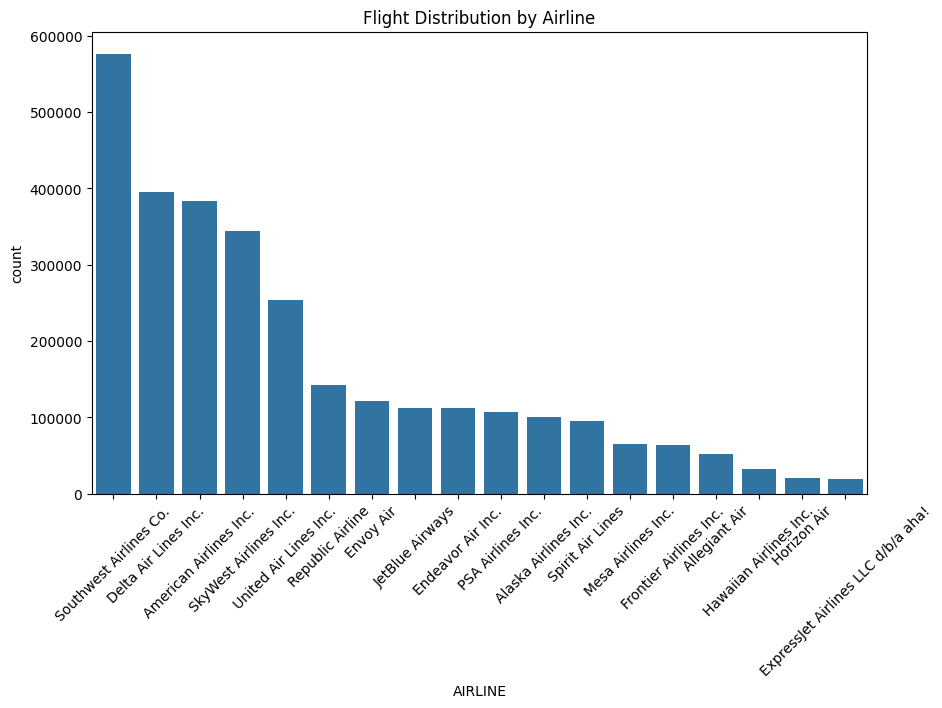

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='AIRLINE', data=df, order=df['AIRLINE'].value_counts().index)
plt.title("Flight Distribution by Airline")
plt.xticks(rotation=45)
plt.show()

**Insight**

~ The graph shows the number of flights operated by each airline.

~ A few airlines operate significantly more flights compared to others.

~ Southwest Airlines and Delta Airlines appear among the airlines with the highest flight counts.

~ Airlines with higher flight volumes manage larger operational networks and serve more routes.

~ Higher flight activity may also increase the chances of delays due to heavy scheduling and operational pressure.

# **Visualization 2**

**2. Busiest Months for Flights**

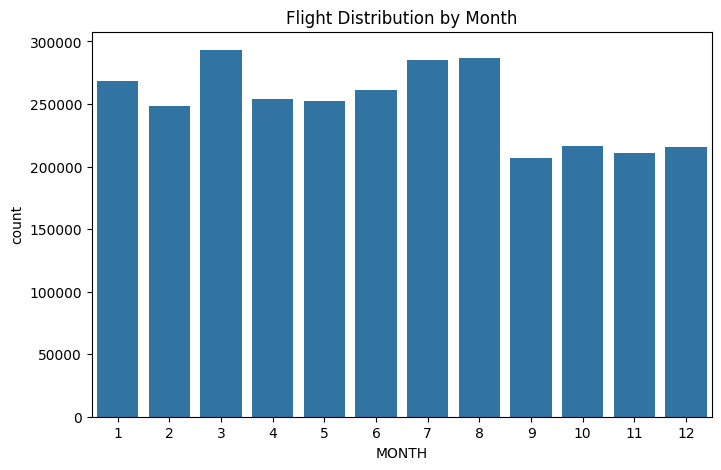

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='MONTH', data=df)
plt.title("Flight Distribution by Month")
plt.show()

**Insight**

~ The graph shows how flight activity varies across different months of the year.

~ Some months have noticeably higher flight volumes, indicating seasonal travel demand.

~ Months such as March, July, and August tend to show higher flight counts,  which may correspond to holiday seasons and peak travel periods.

~ Lower flight counts in certain months may be influenced by reduced travel demand or seasonal operational adjustments.

~ Understanding these trends helps airlines manage capacity and improve scheduling efficiency.

# **Visualization 3**

**3. Flight Distribution by Day of Week**

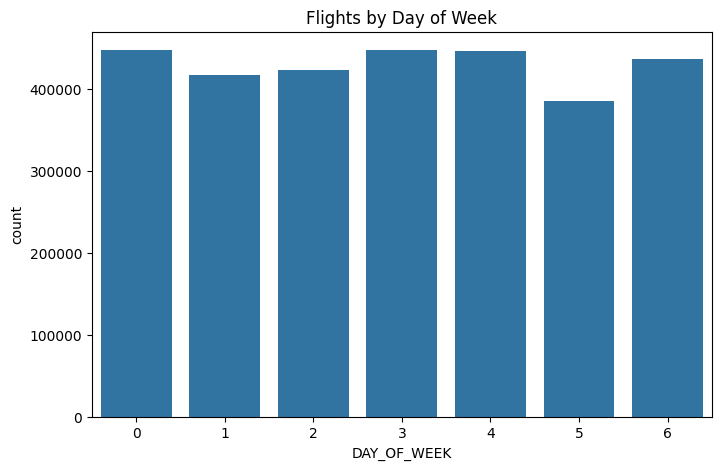

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='DAY_OF_WEEK', data=df)
plt.title("Flights by Day of Week")
plt.show()

**Insight**

~ The graph shows how flight activity varies across different months of the year.

~ Some months have noticeably higher flight volumes, indicating seasonal travel demand.

~ Months such as March, July, and August tend to show higher flight counts, which may correspond to holiday seasons and peak travel periods.

~ Lower flight counts in certain months may be influenced by reduced travel demand or seasonal operational adjustments.

~ Understanding these trends helps airlines manage capacity and improve scheduling efficiency.

# **Visualization 4**

**4. Flight Distribution by Departure Hour**

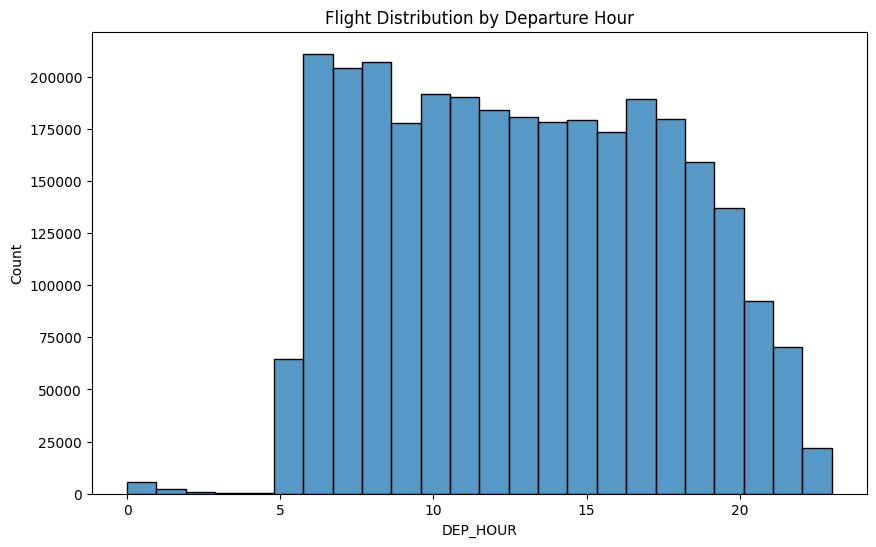

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['DEP_HOUR'], bins=24)
plt.title("Flight Distribution by Departure Hour")
plt.show()

**Insight**

~ The histogram shows how flights are distributed across different departure hours of the day.

~ Most flights depart between early morning and evening hours, indicating peak operational activity during daytime.

~ Flight departures increase significantly after 5 AM, when airport operations typically begin.

~ The highest concentration of flights appears between 6 AM and 6 PM, which reflects the busiest travel period for airlines.

~ Late-night departures are fewer, likely due to lower passenger demand and limited airport operations during nighttime.

# Visualization 5

**5. Top 10 Busiest Routes**

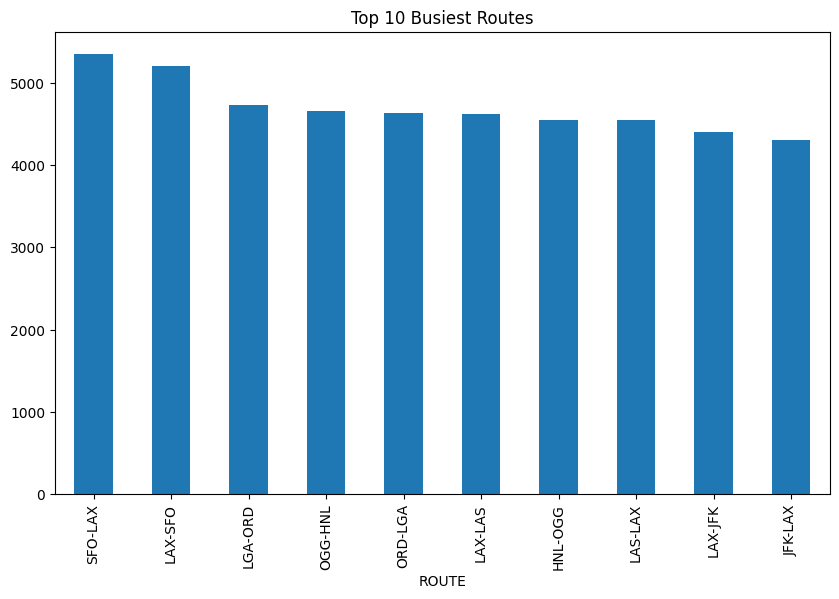

In [ ]:
top_routes = df['ROUTE'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_routes.plot(kind='bar')
plt.title("Top 10 Busiest Routes")
plt.show()

**Insight**

~ The chart highlights the top 10 busiest flight routes based on the number of flights.

~ Routes such as SFO–LAX and LAX–SFO show the highest flight frequency, indicating strong travel demand between these major airports.

~ Many of the busiest routes connect large metropolitan cities and major aviation hubs, where passenger traffic is naturally high.

~ High traffic on these routes suggests that airlines allocate more flights to meet passenger demand and maintain connectivity between key locations.

~ These routes are also likely to experience higher congestion and operational pressure, which may contribute to delays.

# Visualization 6

**6. Departure Delay Distribution**

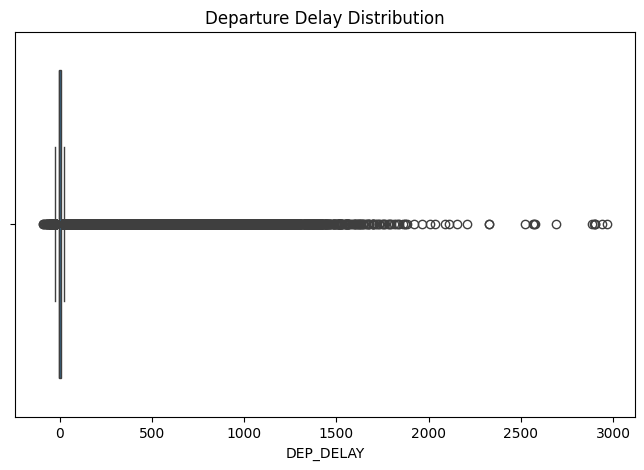

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['DEP_DELAY'])
plt.title("Departure Delay Distribution")
plt.show()

**Insight**

~ The boxplot shows the distribution of departure delays across all flights.

~ Most flights have small delays or depart close to the scheduled time, as indicated by the concentration of values near zero.

~ However, the presence of many outliers on the right side indicates that some flights experience extremely long delays.

~ These extreme delays may occur due to factors such as weather conditions, technical issues, airport congestion, or operational disruptions.

~ Overall, while the majority of flights operate near schedule, occasional severe delays significantly affect the overall delay distribution.

# Visualization 7

**7. Delay Causes Comparison**

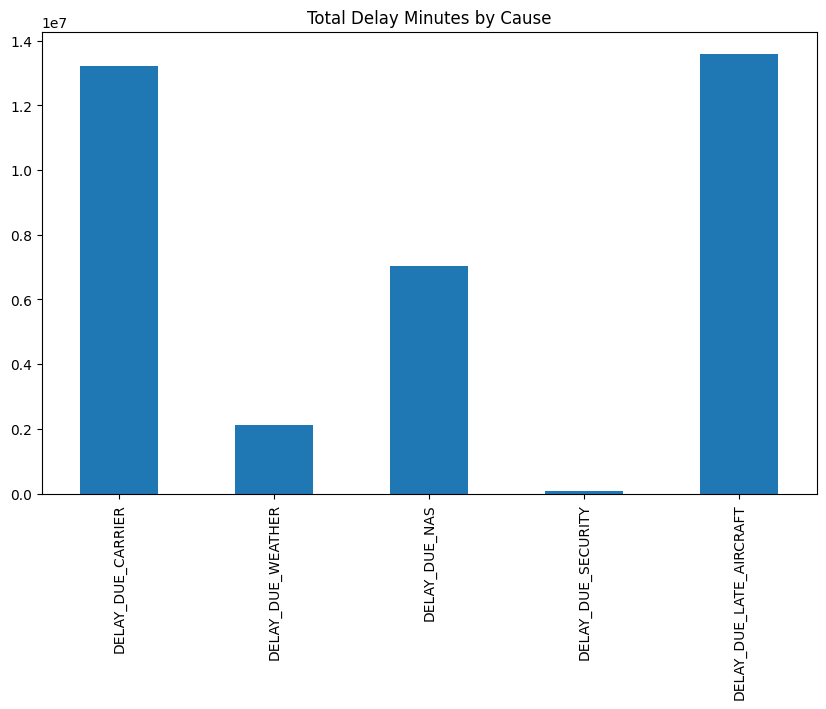

In [ ]:
delay_causes = [
'DELAY_DUE_CARRIER',
'DELAY_DUE_WEATHER',
'DELAY_DUE_NAS',
'DELAY_DUE_SECURITY',
'DELAY_DUE_LATE_AIRCRAFT'
]

df[delay_causes].sum().plot(kind='bar', figsize=(10,6))
plt.title("Total Delay Minutes by Cause")
plt.show()

**Insight**

~ The bar chart compares total delay minutes caused by different factors in airline operations.

~ Late aircraft delays and carrier-related delays contribute the largest portion of total delay time.

~ This indicates that operational issues such as aircraft availability, scheduling problems, and airline management decisions significantly affect flight punctuality.

~ NAS (National Airspace System) delays also account for a notable portion of delays, which may occur due to air traffic congestion and airport operations.

~ Weather delays contribute a smaller but still important share, as adverse weather conditions can disrupt flight schedules.

~ Security-related delays appear to have the least impact compared to other delay causes.

# Visualization 8

**8. Average Delay by Hour**

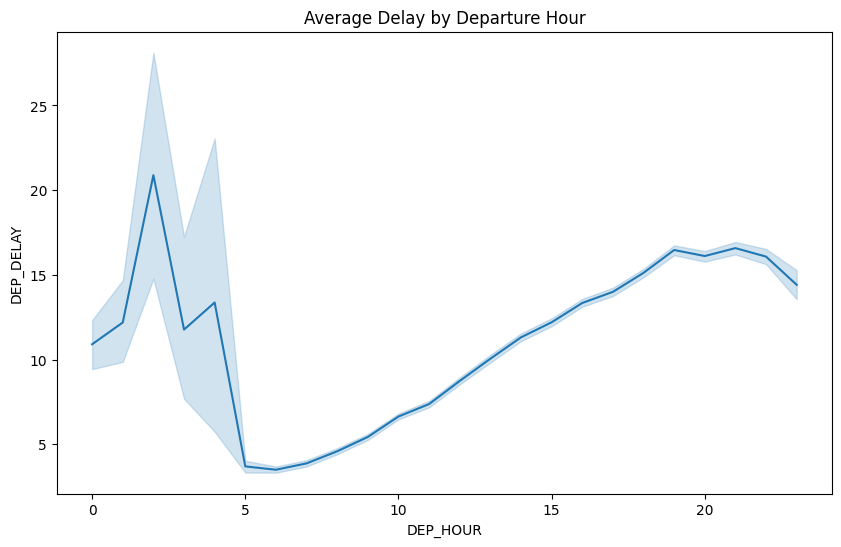

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(x='DEP_HOUR', y='DEP_DELAY', data=df)
plt.title("Average Delay by Departure Hour")
plt.show()

**Insight**

~ The line graph shows how the average departure delay changes across different hours of the day.

~ Early morning flights tend to have lower average delays, as operations start fresh and there are fewer accumulated disruptions.

~ As the day progresses, the average delay gradually increases due to cascading delays from earlier flights, airport congestion, and operational constraints.

~ The highest delays are typically observed during the evening hours, when flight schedules are more crowded and delays from earlier flights accumulate.

~ This pattern highlights the importance of efficient scheduling and operational management to minimize delays throughout the day.

# Final Conclusion

The visual exploration of airline flight data reveals several important operational patterns. The analysis shows that certain airlines operate a larger number of flights compared to others, indicating their strong presence in the aviation network. Flight activity also varies across months and days of the week, reflecting seasonal and weekly travel demand.

The route analysis highlights that major airport connections experience the highest traffic, as they serve as important transportation hubs. Delay analysis indicates that operational factors such as carrier delays and late aircraft contribute significantly to flight delays. Additionally, the analysis of departure hours shows that delays tend to increase later in the day due to accumulated operational disruptions.

Overall, the visualizations provide meaningful insights into airline operations, flight distribution, and delay patterns. These insights can help airlines and airport authorities better understand operational challenges and improve scheduling efficiency to minimize delays.